# Project 9: Autocomplete and Autocorrect Data Analytics
**Oasis Infobyte - Level 2**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import defaultdict, Counter
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
print('Libraries ready!')

Libraries ready!


## Step 1: Build Text Corpus

In [2]:
corpus = """
the quick brown fox jumps over the lazy dog
data science is the study of data to extract meaningful insights
machine learning is a method of data analysis that automates model building
python is a programming language that lets you work quickly
artificial intelligence is the simulation of human intelligence by machines
natural language processing is a branch of artificial intelligence
deep learning is part of a broader family of machine learning methods
data analytics involves examining datasets to draw conclusions about the data
statistics is the discipline that concerns collection analysis and interpretation of data
cloud computing is the on demand availability of computer system resources
big data refers to data sets that are too large to be dealt with by traditional methods
data visualization is the graphical representation of information and data
predictive analytics uses statistical algorithms and machine learning techniques
business intelligence combines analytics data mining and data visualization
the data scientist must be able to code and have knowledge of statistics
feature engineering is the process of using domain knowledge to extract features
supervised learning is a type of machine learning trained on labeled data
unsupervised learning is a type of machine learning that looks for patterns in data
neural networks are computing systems inspired by biological neural networks
python pandas library provides data structures and data analysis tools
numpy library provides support for large multi dimensional arrays and matrices
data cleaning is the process of fixing or removing incorrect duplicate data
exploratory data analysis is an approach to analyzing data sets to summarize characteristics
"""

def preprocess(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    return text.split()

tokens = preprocess(corpus)
print(f'Total tokens: {len(tokens)}')
print(f'Unique words: {len(set(tokens))}')
print(f'Sample: {tokens[:10]}')

Total tokens: 259
Unique words: 139
Sample: ['the', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog', 'data']


## Step 2: Word Frequency Analysis

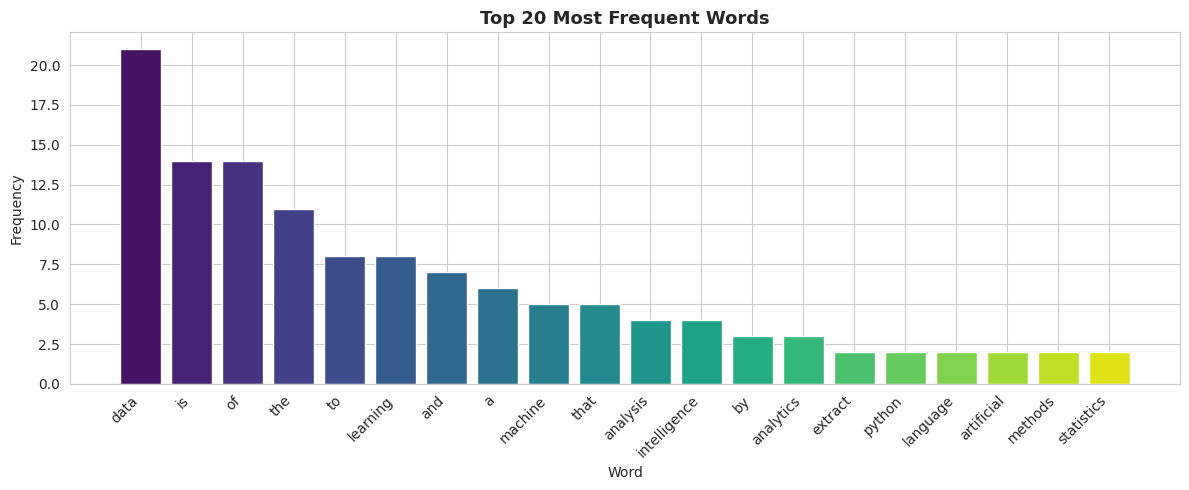

Vocabulary size: 139


In [3]:
word_freq = Counter(tokens)
top_words = word_freq.most_common(20)
words, counts = zip(*top_words)
plt.figure(figsize=(12,5))
plt.bar(words, counts, color=sns.color_palette('viridis',20))
plt.title('Top 20 Most Frequent Words', fontsize=13, fontweight='bold')
plt.xlabel('Word'); plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()
vocab = set(tokens)
print(f'Vocabulary size: {len(vocab)}')

## Step 3: Autocomplete - N-gram Model

In [4]:
class NgramModel:
    def __init__(self, n=2):
        self.n = n
        self.model = defaultdict(Counter)
    def train(self, tokens):
        for i in range(len(tokens)-self.n):
            prefix = tuple(tokens[i:i+self.n-1])
            next_word = tokens[i+self.n-1]
            self.model[prefix][next_word] += 1
        print(f'{self.n}-gram trained: {len(self.model)} prefixes')
    def predict(self, words, k=5):
        prefix = tuple(words[-(self.n-1):])
        if prefix in self.model:
            return [w for w,_ in self.model[prefix].most_common(k)]
        return []

bigram = NgramModel(n=2); bigram.train(tokens)
trigram = NgramModel(n=3); trigram.train(tokens)

print("=== Autocomplete Suggestions ===")
for word in [['data'],['machine'],['deep'],['natural'],['python']]:
    sug = bigram.predict(word)
    print(f'Input: "{word[0]}" -> {sug}')

2-gram trained: 137 prefixes
3-gram trained: 219 prefixes
=== Autocomplete Suggestions ===
Input: "data" -> ['analysis', 'sets', 'visualization', 'science', 'to']
Input: "machine" -> ['learning']
Input: "deep" -> ['learning']
Input: "natural" -> ['language']
Input: "python" -> ['is', 'pandas']


## Step 4: Autocorrect - Levenshtein Distance

In [5]:
def levenshtein(s1, s2):
    m, n = len(s1), len(s2)
    dp = [[0]*(n+1) for _ in range(m+1)]
    for i in range(m+1): dp[i][0] = i
    for j in range(n+1): dp[0][j] = j
    for i in range(1,m+1):
        for j in range(1,n+1):
            if s1[i-1]==s2[j-1]: dp[i][j]=dp[i-1][j-1]
            else: dp[i][j]=1+min(dp[i-1][j],dp[i][j-1],dp[i-1][j-1])
    return dp[m][n]

def autocorrect(word, vocab, k=3):
    dists = {w: levenshtein(word,w) for w in vocab}
    return sorted(dists.items(), key=lambda x: x[1])[:k]

print("=== Autocorrect Results ===")
for word in ['dataa','lerning','statisics','algorihtm','mashine']:
    corrections = autocorrect(word, vocab)
    print(f'"{word}" -> {corrections[0][0]} (suggestions: {[w for w,_ in corrections]})')

=== Autocorrect Results ===
"dataa" -> data (suggestions: ['data', 'draw', 'the'])
"lerning" -> learning (suggestions: ['learning', 'cleaning', 'mining'])
"statisics" -> statistics (suggestions: ['statistics', 'statistical', 'matrices'])
"algorihtm" -> algorithms (suggestions: ['algorithms', 'about', 'arrays'])
"mashine" -> machine (suggestions: ['machine', 'machines', 'matrices'])


## Step 5: Performance Metrics & Visualization

Accuracy: 80.0%
Misspelled    Expected         Got  Correct  EditDist
     dataa        data        data     True         1
   lerning    learning    learning     True         1
 statisics  statistics  statistics     True         1
 algorihtm   algorithm  algorithms    False         3
   mashine     machine     machine     True         1
artificail  artificial  artificial     True         2
  analtics   analytics   analytics     True         1
 procesing  processing  processing     True         1
 visulaize   visualize   summarize    False         5
prgramming programming programming     True         1


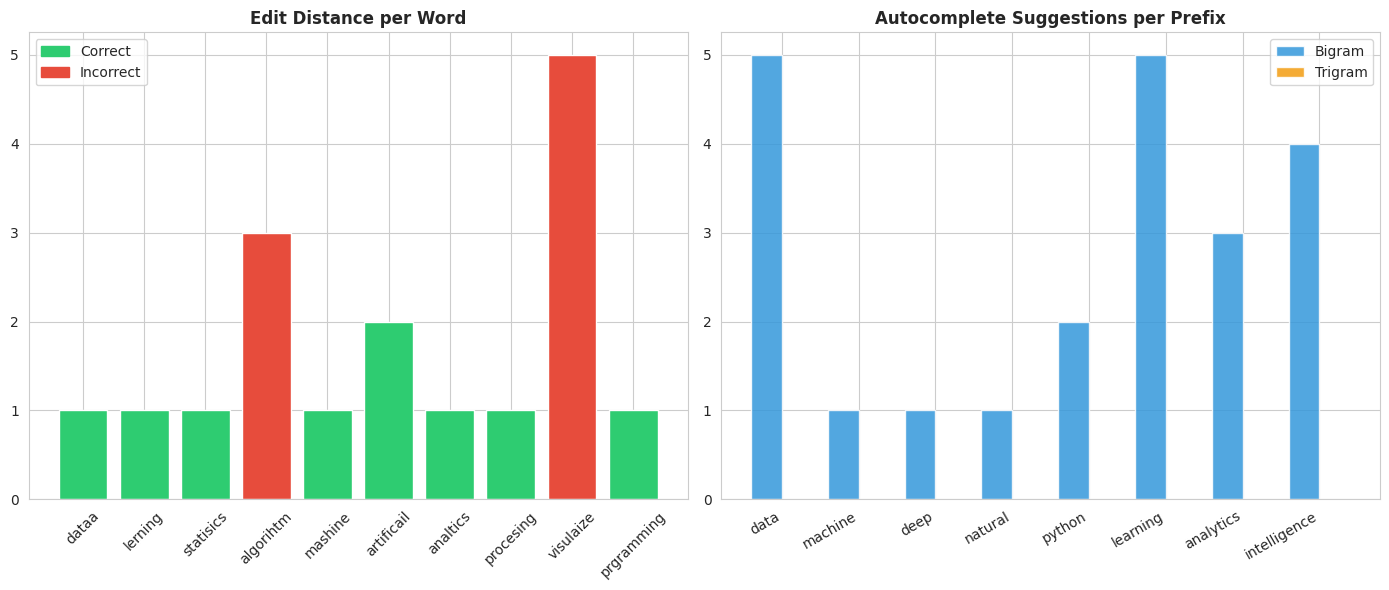

In [6]:
test_pairs = [
    ('dataa','data'),('lerning','learning'),('statisics','statistics'),
    ('algorihtm','algorithm'),('mashine','machine'),('artificail','artificial'),
    ('analtics','analytics'),('procesing','processing'),('visulaize','visualize'),
    ('prgramming','programming')
]
rows = []
correct = 0
for misspelled, expected in test_pairs:
    suggestions = autocorrect(misspelled, vocab)
    top = suggestions[0][0]
    is_correct = top == expected
    if is_correct: correct += 1
    rows.append({'Misspelled':misspelled,'Expected':expected,'Got':top,
                 'Correct':is_correct,'EditDist':suggestions[0][1]})

results_df = pd.DataFrame(rows)
print(f'Accuracy: {correct/len(test_pairs)*100:.1f}%')
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1,2,figsize=(14,6))
colors = ['#2ECC71' if c else '#E74C3C' for c in results_df['Correct']]
axes[0].bar(results_df['Misspelled'], results_df['EditDist'], color=colors)
axes[0].set_title('Edit Distance per Word', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
legend_els = [Patch(color='#2ECC71',label='Correct'), Patch(color='#E74C3C',label='Incorrect')]
axes[0].legend(handles=legend_els)

prefixes = ['data','machine','deep','natural','python','learning','analytics','intelligence']
bigram_hits = [len(bigram.predict([p])) for p in prefixes]
trigram_hits = [len(trigram.predict([p])) for p in prefixes]
x = np.arange(len(prefixes))
axes[1].bar(x-0.2, bigram_hits, 0.4, label='Bigram', color='#3498DB', alpha=0.85)
axes[1].bar(x+0.2, trigram_hits, 0.4, label='Trigram', color='#F39C12', alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(prefixes, rotation=30, ha='right')
axes[1].set_title('Autocomplete Suggestions per Prefix', fontweight='bold')
axes[1].legend()
plt.tight_layout(); plt.show()